# <p style="background-color: black;font-family:Algerian;font-size:150%;text-align:center;color:orange;border-radius:1000px 50px;">Orange Disease Prediction </p>

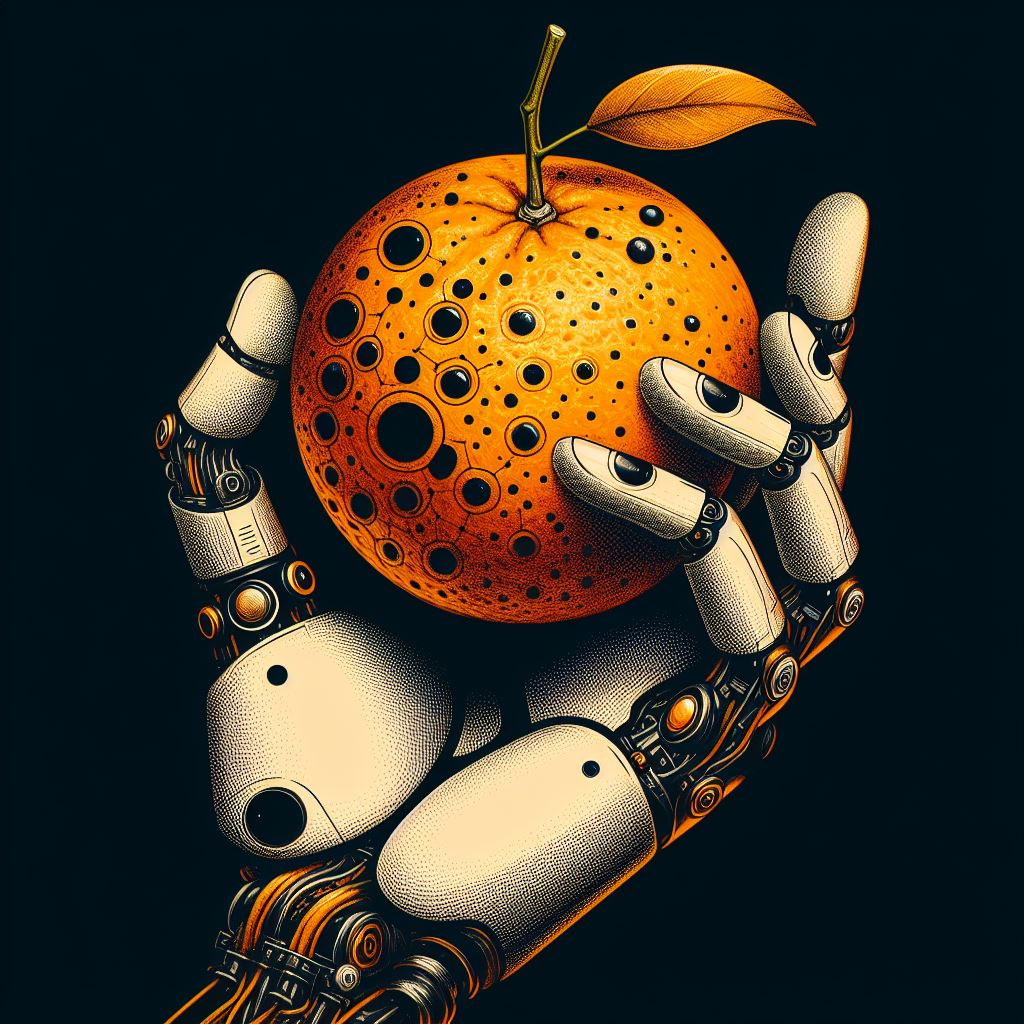

# <p style="background-color: black;font-family:Algerian;font-size:150%;text-align:center;color:orange;border-radius:1000px 50px;">About the Auther</p>

<div style="border: 2px solid orange; padding: 10px; max-width: 1500px;">
    <p>
        I am <b>Saman Fatima</b>, a passionate data scientist dedicated to mastering machine learning techniques and continually expanding my knowledge base. I believe in the mantra of KeepLearning and KeepSupporting, as I am committed to constant growth and uplifting others in the field.
    </p>
    <div style="text-align: center;">
        <img src="https://media.licdn.com/dms/image/D4D03AQFAcZhjvE7C0Q/profile-displayphoto-shrink_800_800/0/1714558384812?e=1721260800&v=beta&t=vfqq1fnuYMej7Tpr_MGPhs1c9DuVyJHbzZT0XuacRds" alt="Profile Picture" style="width: 100px; height: 100px; border-radius: 50%; border: 2px solid orange;"><br>
    </div>
    <p>
        You can find more about me on my <a href="https://www.linkedin.com/in/saman-fatima-datascience/" target="_blank">LinkedIn</a>.<br>
        Feel free to connect and reach out for any collaboration or queries!
    </p>
</div>

# <p style="background-color: black;font-family:Algerian;font-size:150%;text-align:center;color:orange;border-radius:1000px 50px;">Importing the libraries</p>


In [44]:
# importing the important libraries 
import pandas as pd 
import warnings
import numpy as np 
import os
import matplotlib.pyplot as plt 
import seaborn as sns 
import tensorflow as tf 
from tensorflow import keras 
from keras import Sequential
import matplotlib.image as mpimg
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,Dropout
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=FutureWarning)  # Suppress FutureWarning messages


# <p style="background-color: black;font-family:Algerian;font-size:150%;text-align:center;color:orange;border-radius:1000px 50px;">Loading The Dataset </p>



In [45]:
# Set seed for reproducibility
seed = 123

# Define the directory paths for the training and validation datasets
train_dir = '/kaggle/input/orange-diseases-dataset/dataset/train'
validation_dir = '/kaggle/input/orange-diseases-dataset/dataset/test'

# Use the image_dataset_from_directory function to create training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    directory=train_dir,
    labels="inferred",
    label_mode="int",  # Use "categorical" for categorical labels
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(256, 256),
    validation_split=0.2,
    subset="training",
    seed=seed
)

# Use the image_dataset_from_directory function to create validation dataset
validation_ds = tf.keras.utils.image_dataset_from_directory(
    directory=validation_dir,
    labels="inferred",
    label_mode="int",  # Use "categorical" for categorical labels
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(256, 256),
    validation_split=0.2,
    subset="validation",
    seed=seed
)


Found 1164 files belonging to 4 classes.
Using 932 files for training.
Found 626 files belonging to 4 classes.
Using 125 files for validation.


# <p style="background-color: black;font-family:Algerian;font-size:150%;text-align:center;color:orange;border-radius:1000px 50px;">visualizing the data</p>



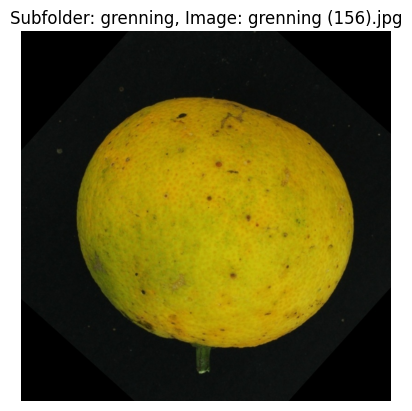

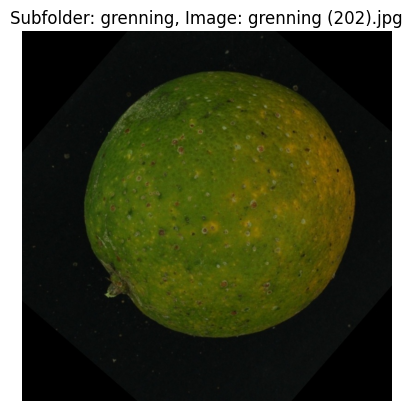

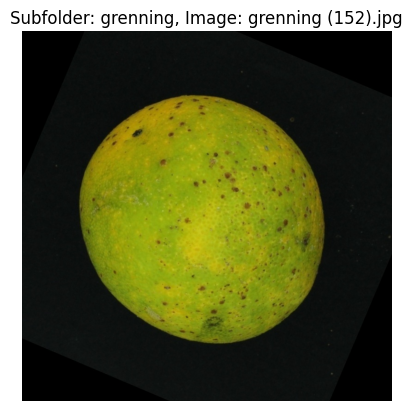

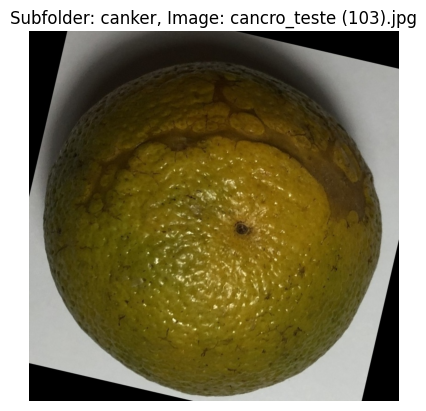

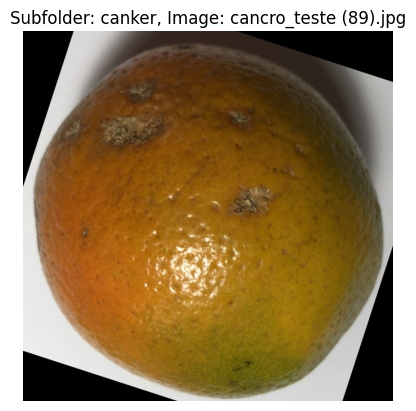

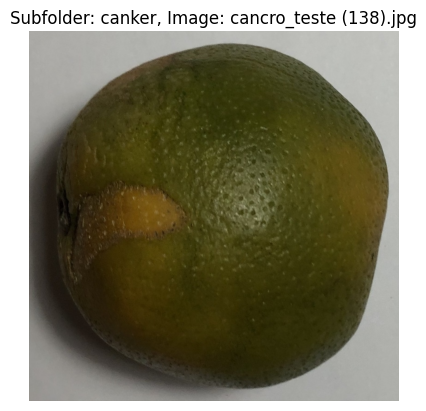

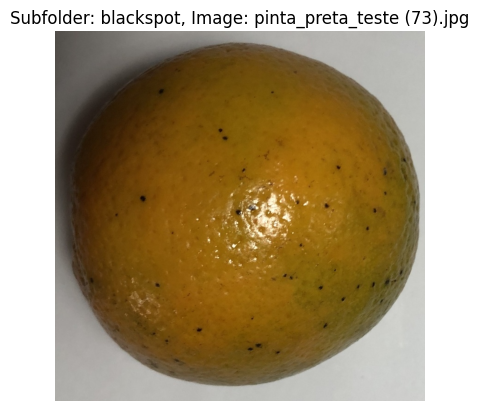

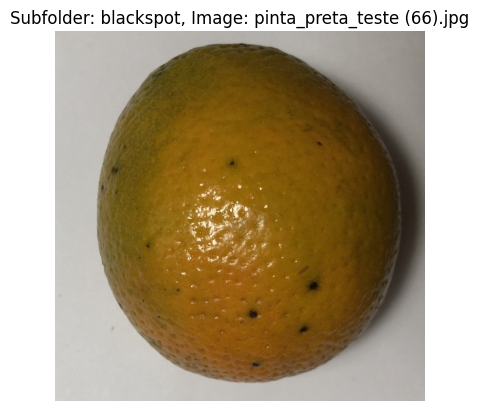

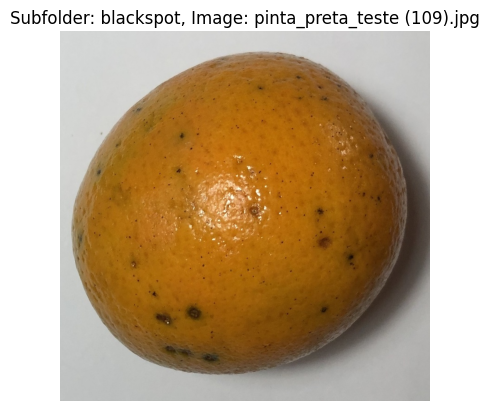

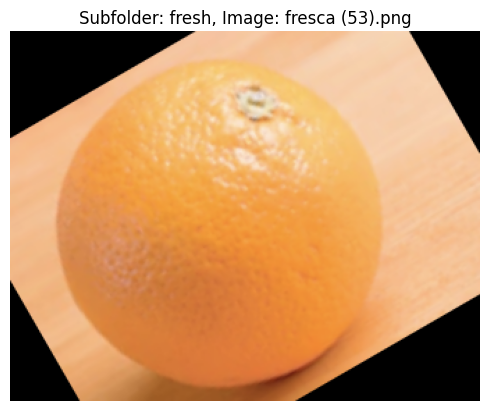

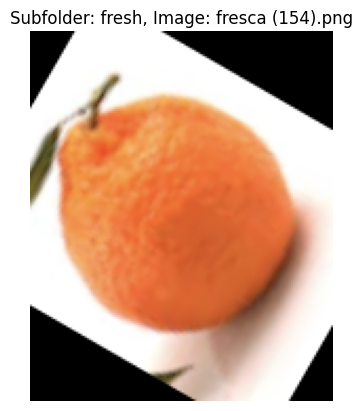

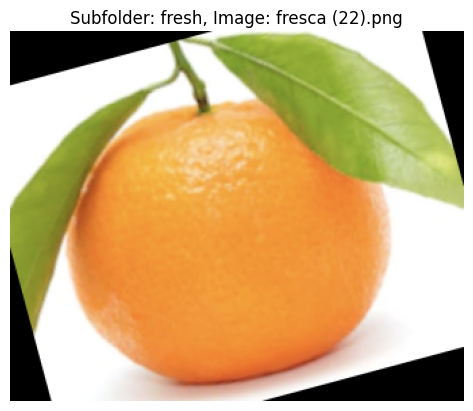

In [46]:
# Path to the main folder
main_folder = '/kaggle/input/orange-diseases-dataset/dataset/test'

# Display images from each subfolder
for subfolder in os.listdir(main_folder):
    subfolder_path = os.path.join(main_folder, subfolder)
    if os.path.isdir(subfolder_path):
        # Display images from the subfolder
        for image_file in os.listdir(subfolder_path)[:3]:
            image_path = os.path.join(subfolder_path, image_file)
            image = mpimg.imread(image_path)
            plt.imshow(image)
            plt.title(f'Subfolder: {subfolder}, Image: {image_file}')
            plt.axis('off')
            plt.show()


# <p style="background-color: black;font-family:Algerian;font-size:150%;text-align:center;color:orange;border-radius:1000px 50px;">Data Normalization </p>


In [47]:
# Normalizing the data 
def process(image,label):
    image = tf.cast(image/255,tf.float32)
    return image,label
train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [48]:
# Get the directory path from the DirectoryIterator object
dataset_path = '/kaggle/input/orange-diseases-dataset/dataset/train'

# Count the number of subdirectories (classes)
num_classes = len([name for name in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, name))])

print("Number of classes:", num_classes)

Number of classes: 4


# <p style="background-color: black;font-family:Algerian;font-size:150%;text-align:center;color:orange;border-radius:1000px 50px;">power of pretrained models</p>



In [49]:
from tensorflow.keras.applications import VGG16 ,Xception

conv_base = Xception(
    weights='imagenet',
    include_top = False,
    input_shape=(256,256,3),
    pooling='avg'
)

In [50]:
conv_base.trainable = False

In [51]:
model = Sequential()
model.add(conv_base)
model.add(BatchNormalization())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.35))
model.add(BatchNormalization())
model.add(Dense(120, activation='relu'))
model.add(Dense(4, activation='softmax'))

# <p style="background-color: black;font-family:Algerian;font-size:150%;text-align:center;color:orange;border-radius:1000px 50px;">compiling the model </p>


In [52]:
model.compile(optimizer=Adam(lr=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [53]:
history = model.fit(train_ds, epochs=100, validation_data=validation_ds,callbacks=[EarlyStopping(patience=0)])


Epoch 1/100
30/30 [==============================] - 9s 145ms/step - loss: 0.2852 - accuracy: 0.8863 - val_loss: 0.3562 - val_accuracy: 0.9280
Epoch 2/100
30/30 [==============================] - 4s 117ms/step - loss: 0.0871 - accuracy: 0.9753 - val_loss: 0.2578 - val_accuracy: 0.9680
Epoch 3/100
30/30 [==============================] - 4s 119ms/step - loss: 0.0522 - accuracy: 0.9828 - val_loss: 0.2099 - val_accuracy: 0.9680
Epoch 4/100
30/30 [==============================] - 4s 120ms/step - loss: 0.0490 - accuracy: 0.9861 - val_loss: 0.2461 - val_accuracy: 0.9520


# <p style="background-color: black;font-family:Algerian;font-size:150%;text-align:center;color:orange;border-radius:1000px 50px;">model evaluation


In [54]:
# Evaluate the model on the validation dataset
validation_loss, validation_accuracy = model.evaluate(validation_ds)

# Print the validation loss and accuracy
print("Validation Loss:", validation_loss)
print("Validation Accuracy:", validation_accuracy)

4/4 [==============================] - 1s 95ms/step - loss: 0.2461 - accuracy: 0.9520
Validation Loss: 0.24612915515899658
Validation Accuracy: 0.9520000219345093


> If you find this notebook helpful, please consider giving it an upvote! Your support means a lot. Thank you!

# <p style="background-color: black;font-family:Algerian;font-size:150%;text-align:center;color:orange;border-radius:1000px 50px;">the end</p>

